In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [42]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f6
function_folder = os.path.join(base_dir, "function_6")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f6 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 6: shape = {df_f6.shape}, columns = {df_f6.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']


In [43]:
week1_results = {"f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064)}

In [44]:
week2_results = {"f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203)}

In [45]:
week3_results = {"f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669)}

In [46]:
week4_results = {"f6": ([0.494472, 0.050000, 0.451934, 0.152883, 0.386469], -1.421729209627387)}

In [47]:
week5_results = {"f6": ([0.666300, 0.229100, 0.516000, 0.789473, 0.315789], -0.7791148650103992)}

In [48]:
week6_results = {"f6": ([0.537637, 0.403865, 0.951610, 0.943059, 0.050967], -0.6814591029200937)}

In [49]:
week7_results = {"f6": ([0.212341, 0.007631, 0.955851, 0.999487, 0.763435], -1.8381389462062772)}

In [50]:
week8_results = {"f6": ([0.987971, 0.066922, 0.908036, 0.000615, 0.964637], -2.7568441153569343)}

In [51]:
week9_results = {"f6": ([0.553475, 0.343241, 0.535219, 0.771873, 0.140689], -0.24936021594704408)}

In [52]:
week10_results = {"f6": ([0.500199, 0.440981, 0.607396, 0.749856, 0.063960], -0.2244249365413683)}

In [53]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f6

for week, results in weekly_results.items():
    
    if "f6" not in results:
        continue
    
    inputs, output = results["f6"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f6
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "X5", "y1"]
    )
    
    # append to df_f5
    df_f6 = pd.concat([df_f6, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f6 = df_f6.drop_duplicates(ignore_index=True)

print("updated f6 shape:", df_f6.shape)


updated f6 shape: (30, 6)


In [54]:
print(df_f6)

          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820  0.109476  0.877888 -2

In [55]:
display(df_f6.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,30.0,0.545135,0.271339,0.021735,0.376834,0.545556,0.750576,0.987971
X2,30.0,0.442904,0.301147,0.001300,0.230742,0.349536,0.739984,0.931871
X3,30.0,0.535076,0.303330,0.016523,0.361796,0.525610,0.791694,0.978806
X4,30.0,0.591297,0.308419,0.000615,0.364471,0.687256,0.813430,1.000000
X5,30.0,0.383281,0.305711,0.000000,0.111077,0.322312,0.610725,0.964637
y1,30.0,-1.329267,0.624534,-2.756844,-1.700504,-1.301682,-0.791645,-0.224425


## Feature vs y scatter plots

Feature vs y1 for f6 with conditional region visualisation


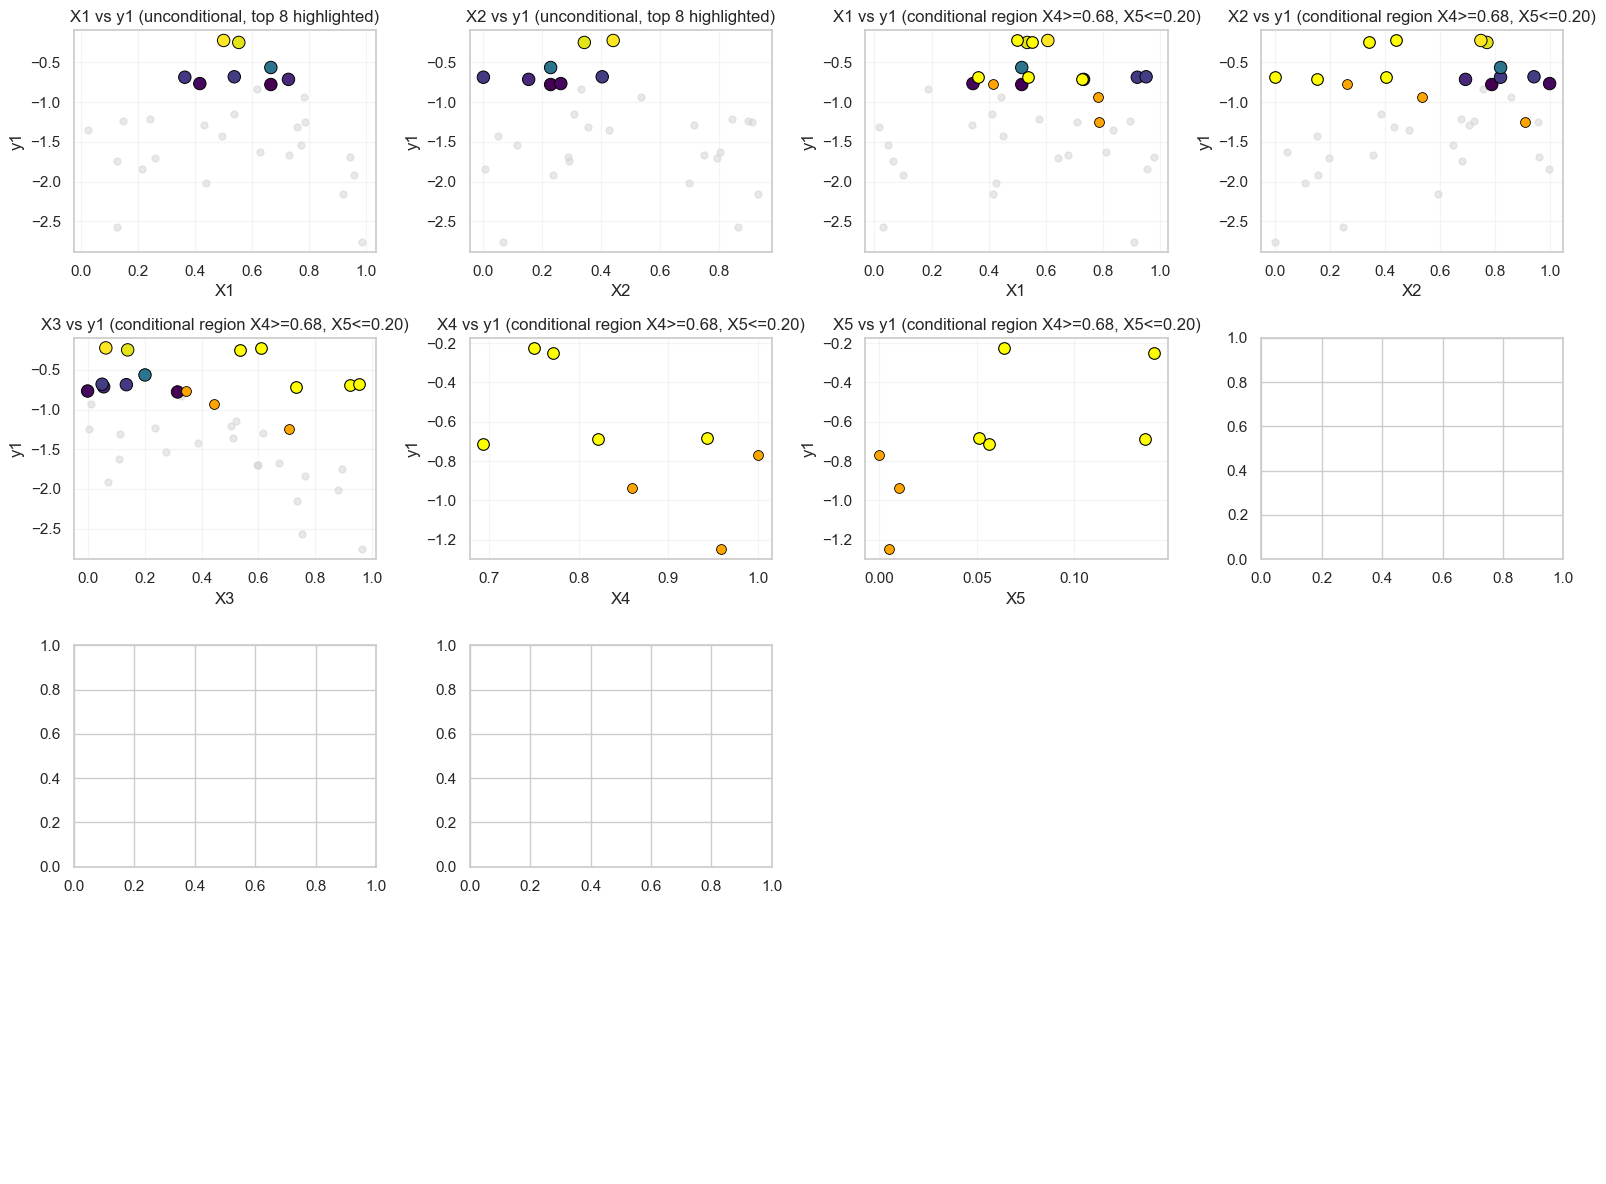

In [56]:
print("Feature vs y1 for f6 with conditional region visualisation")

# extract inputs and output for f6
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
X_f6 = df_f6[input_cols_f6].values
y_f6 = df_f6["y1"].values

# identify top 8 globally
top8_idx = np.argsort(y_f6)[-8:]
y_top8 = y_f6[top8_idx]
X_top8 = X_f6[top8_idx]

# conditional region mask
mask_cond = (df_f6["X4"] >= 0.68) & (df_f6["X5"] <= 0.20)
X_cond = X_f6[mask_cond]
y_cond = y_f6[mask_cond]

# rank within conditional region
order_cond = np.argsort(y_cond)
top5_idx = order_cond[-5:]
next5_idx = order_cond[-10:-5]
rest_idx = order_cond[:-10]

# number of features
n_features = X_f6.shape[1]
ncols = 4
nrows = 2 * int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

axes = axes.ravel().tolist()

# unconditional row
for j, col in enumerate(input_cols_f6):
    ax = axes[j]

    ax.scatter(
        X_f6[:, j],
        y_f6,
        c="lightgray",
        s=25,
        alpha=0.5
    )

    sc = ax.scatter(
        X_top8[:, j],
        y_top8,
        c=y_top8,
        cmap="viridis",
        s=80,
        edgecolor="black",
        linewidth=0.7
    )

    ax.set_xlabel(col)
    ax.set_ylabel("y1")
    ax.set_title(f"{col} vs y1 (unconditional, top 8 highlighted)")
    ax.grid(alpha=0.2)

# conditional row
offset = int(np.ceil(n_features / ncols))

for j, col in enumerate(input_cols_f6):
    ax = axes[offset + j]

    ax.scatter(
        X_cond[rest_idx, j],
        y_cond[rest_idx],
        c="grey",
        s=30,
        alpha=0.6
    )

    ax.scatter(
        X_cond[next5_idx, j],
        y_cond[next5_idx],
        c="orange",
        s=50,
        edgecolor="black",
        linewidth=0.6
    )

    ax.scatter(
        X_cond[top5_idx, j],
        y_cond[top5_idx],
        c="yellow",
        s=70,
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_xlabel(col)
    ax.set_ylabel("y1")
    ax.set_title(f"{col} vs y1 (conditional region X4>=0.68, X5<=0.20)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features * 2, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Distribution Analysis

f6 – feature and output distributions


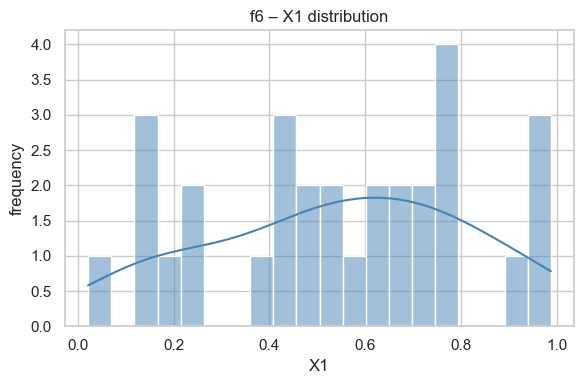

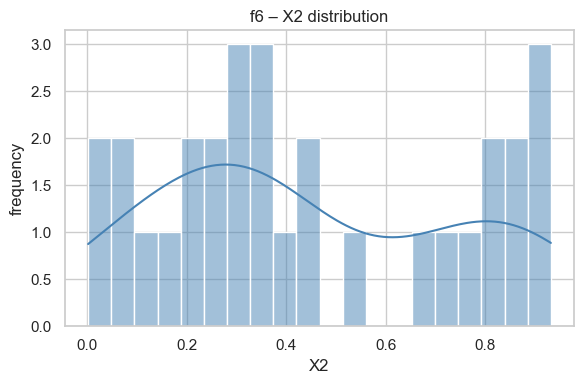

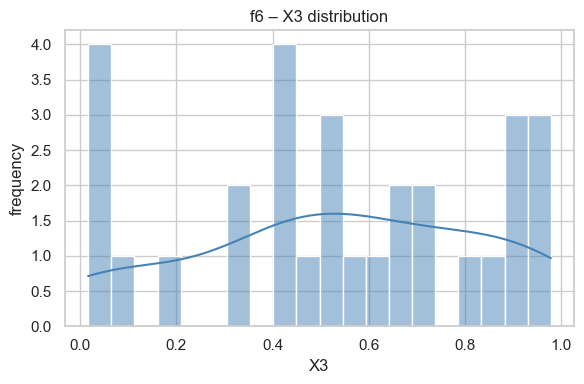

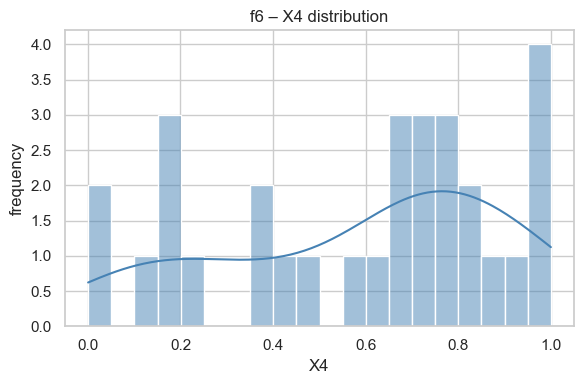

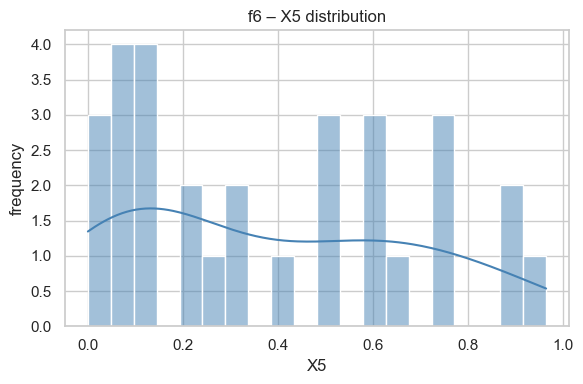

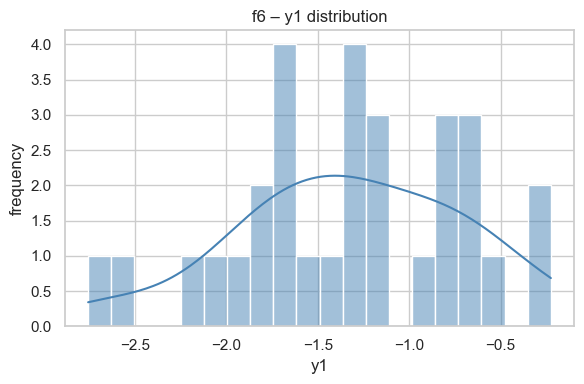

In [57]:
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
output_col_f6 = [c for c in df_f6.columns if c.startswith("y")][0]

print("f6 – feature and output distributions")

all_cols_raw_f6 = input_cols_f6 + [output_col_f6]

for col in all_cols_raw_f6:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f6[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f6 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Y vs Instance Index

f6 – y vs instance index


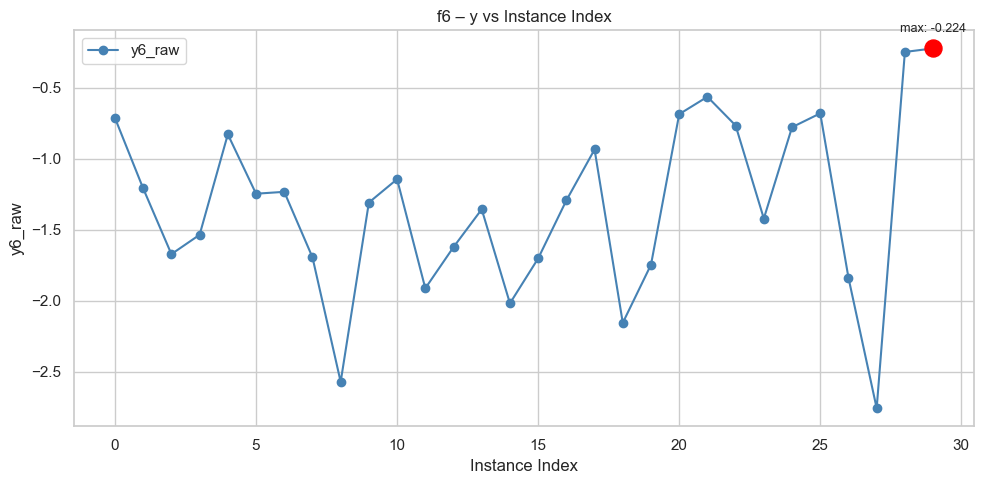

In [58]:
print("f6 – y vs instance index")

# clean copy of raw data
df_f6_plot = df_f6.copy()

# extract raw y
y_raw = df_f6_plot[output_col_f6].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y6_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f6 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y6_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## Pearson Correlation

f6 Pearson Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.173646,-0.048980,-0.061663,-0.227485,-0.058800
X2,-0.173646,1.000000,-0.022607,-0.161579,0.122117,-0.224368
X3,-0.048980,-0.022607,1.000000,0.199195,-0.021992,0.121222
X4,-0.061663,-0.161579,0.199195,1.000000,-0.382003,0.612607
X5,-0.227485,0.122117,-0.021992,-0.382003,1.000000,-0.732837
y1,-0.058800,-0.224368,0.121222,0.612607,-0.732837,1.000000


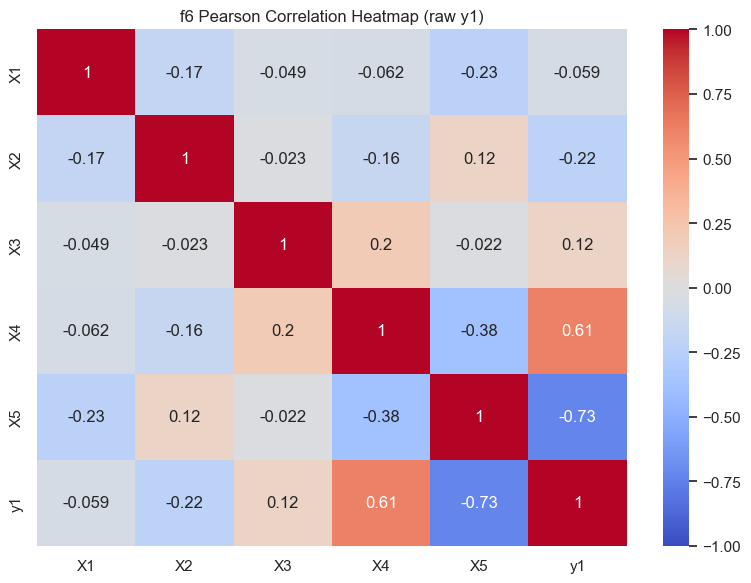

In [59]:
df_raw = df_f6.copy()

print("f6 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f6 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f6 Spearman Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.129506,-0.025367,-0.023807,-0.241629,-0.068528
X2,-0.129506,1.000000,-0.081887,-0.170653,0.027589,-0.157526
X3,-0.025367,-0.081887,1.000000,0.265881,-0.049394,0.135276
X4,-0.023807,-0.170653,0.265881,1.000000,-0.421135,0.585762
X5,-0.241629,0.027589,-0.049394,-0.421135,1.000000,-0.696107
y1,-0.068528,-0.157526,0.135276,0.585762,-0.696107,1.000000


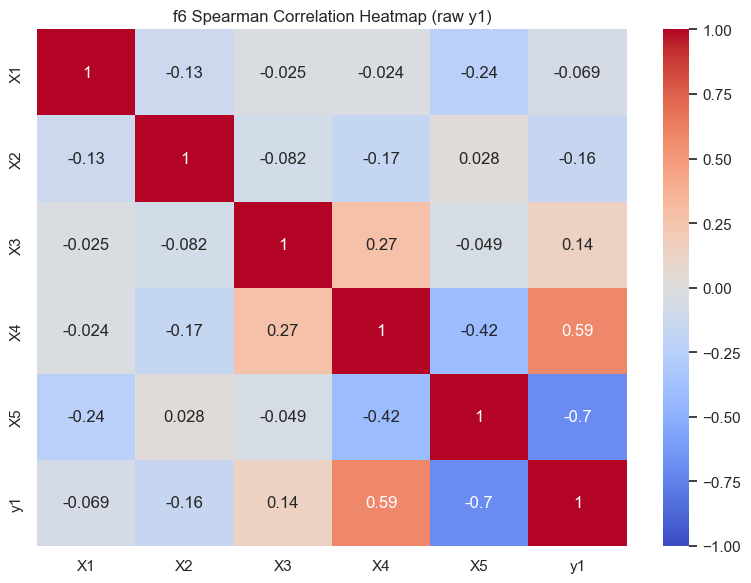

In [60]:
# spearman correlation with raw y1
df_raw = df_f6.copy()

print("f6 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f6 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f6 Kendall Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.119816,-0.013825,0.004603,-0.188723,-0.055236
X2,-0.119816,1.000000,-0.046083,-0.119678,0.000000,-0.115075
X3,-0.013825,-0.046083,1.000000,0.179517,-0.032221,0.110472
X4,0.004603,-0.119678,0.179517,1.000000,-0.337931,0.425287
X5,-0.188723,0.000000,-0.032221,-0.337931,1.000000,-0.508046
y1,-0.055236,-0.115075,0.110472,0.425287,-0.508046,1.000000


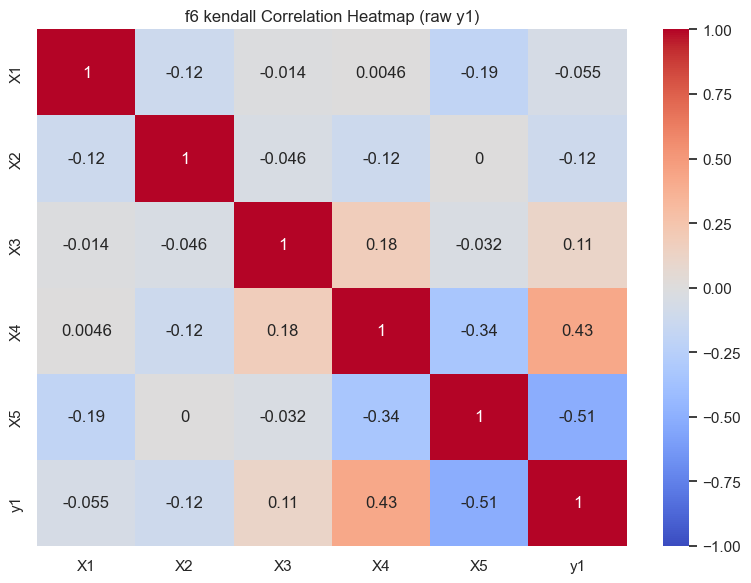

In [61]:
# Kendall correlation with raw y1
df_raw = df_f6.copy()

print("f6 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f6 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information

In [62]:
from sklearn.feature_selection import mutual_info_regression

print("f6 — Mutual Information with Output")

df_f6_raw = df_f6.copy()

# define inputs and output
input_cols_f6 = [c for c in df_f6_raw.columns if c.startswith("X")]
output_col_f6 = "y1"

X_f6 = df_f6_raw[input_cols_f6].values
y_f6 = df_f6_raw[output_col_f6].values

# compute mutual information
mi_f6 = mutual_info_regression(X_f6, y_f6, random_state=42)

# build dataframe
mi_f6_df = pd.DataFrame({
    "Feature": input_cols_f6,
    "Mutual_Info": mi_f6
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f6_df)


f6 — Mutual Information with Output


,Feature,Mutual_Info
4,X5,0.370103
3,X4,0.143482
0,X1,0.017514
1,X2,0.000000
2,X3,0.000000


## Partial Correlation

In [63]:
!pip install pingouin
import pingouin as pg

print("f6 (Raw y1) — Partial Correlation")

df_f6_raw = df_f6.copy()

# define inputs and output
input_cols_f6 = [c for c in df_f6_raw.columns if c.startswith("X")]
output_col_f6 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f6:
    covars = [c for c in input_cols_f6 if c != x]  # all other X's as covariates
    
    pcorr_raw_f6 = pg.partial_corr(
        data=df_f6_raw,
        x=x,
        y=output_col_f6,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f6)


f6 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,30,-0.33901,"[-0.64, 0.06]",0.090229



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,30,-0.225778,"[-0.56, 0.18]",0.26742



Partial correlation for X3:


,n,r,CI95%,p-val
pearson,30,0.052002,"[-0.34, 0.43]",0.800819



Partial correlation for X4:


,n,r,CI95%,p-val
pearson,30,0.478291,"[0.11, 0.73]",0.013453



Partial correlation for X5:


,n,r,CI95%,p-val
pearson,30,-0.726092,"[-0.87, -0.47]",0.000027


## XGBoost Feature Importance 

**Reference:** Hellsten, L., Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2024) Global Trust Region Bayesian Optimization, arXiv preprint arXiv:2504.06111.

- XGBoost provides a non‑linear, tree‑based feature‑importance ranking that independently validates the ARD length‑scale findings for f6, increasing confidence in the identified active dimensions.

  feature      gain    weight     cover
0      X1  0.069475  0.242178  0.197374
1      X2  0.048101  0.178447  0.178429
2      X3  0.045719  0.200463  0.202352
3      X4  0.400329  0.169177  0.216282
4      X5  0.436376  0.209733  0.205562


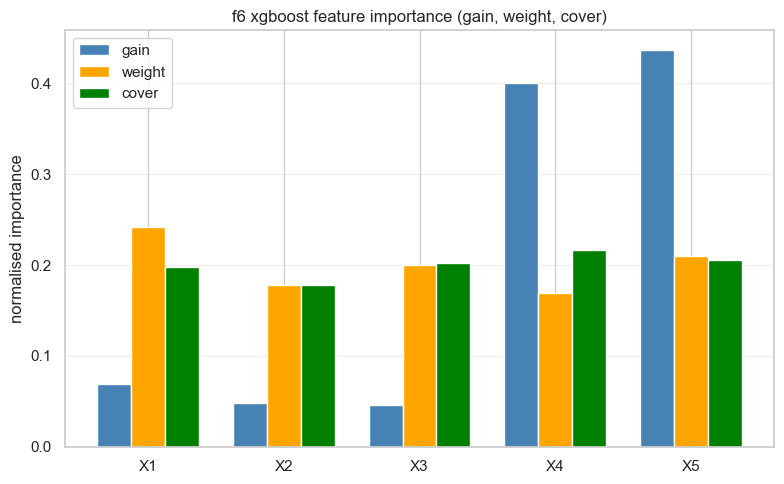

In [64]:
import xgboost as xgb

# extract inputs and output
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
X_f6 = df_f6[input_cols_f6].values
y_f6 = df_f6["y1"].values

# model configuration suitable for n=30
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=1
)

model.fit(X_f6, y_f6)

# gain-based importance (default)
importance_gain = model.feature_importances_

# weight and cover from booster
booster = model.get_booster()
importance_weight_raw = booster.get_score(importance_type="weight")
importance_cover_raw  = booster.get_score(importance_type="cover")
importance_gain_raw   = booster.get_score(importance_type="gain")

# align all three metrics to the feature order
importance_weight = np.array([importance_weight_raw.get(f"f{i}", 0.0) for i in range(len(input_cols_f6))])
importance_cover  = np.array([importance_cover_raw.get(f"f{i}", 0.0) for i in range(len(input_cols_f6))])
importance_gain2  = np.array([importance_gain_raw.get(f"f{i}", 0.0) for i in range(len(input_cols_f6))])

# normalise for comparability
def normalise(v):
    s = v.sum()
    return v / s if s > 0 else v

imp_gain_norm   = normalise(importance_gain)
imp_weight_norm = normalise(importance_weight)
imp_cover_norm  = normalise(importance_cover)

# assemble dataframe
df_imp = pd.DataFrame({
    "feature": input_cols_f6,
    "gain": imp_gain_norm,
    "weight": imp_weight_norm,
    "cover": imp_cover_norm
})

print(df_imp)

# plot
plt.figure(figsize=(8, 5))
width = 0.25
x = np.arange(len(input_cols_f6))

plt.bar(x - width, imp_gain_norm,   width=width, label="gain",   color="steelblue")
plt.bar(x,         imp_weight_norm, width=width, label="weight", color="orange")
plt.bar(x + width, imp_cover_norm,  width=width, label="cover",  color="green")

plt.xticks(x, input_cols_f6)
plt.ylabel("normalised importance")
plt.title("f6 xgboost feature importance (gain, weight, cover)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## fANOVA implementation

**Reference:** Wang, Z., Eriksson, D. and Gardner, J. (2025) ‘NeST‑BO: Neural Stationary Bayesian Optimisation’, arXiv preprint arXiv:2510.05516.

- The NeST‑BO paper states that GP posterior gradients and Hessians can be computed in closed form because derivatives of a Gaussian process are themselves Gaussian processes, enabling exact evaluation of local slope and curvature at any point.

In [65]:
from sklearn.ensemble import RandomForestRegressor

# extract inputs and output
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
X_f6 = df_f6[input_cols_f6].values
y_f6 = df_f6["y1"].values

# random forest for fanova
rf = RandomForestRegressor(
    n_estimators=1000,
    max_features=None,
    min_samples_leaf=1,
    max_depth=None,
    random_state=42,
    n_jobs=1
)

rf.fit(X_f6, y_f6)

# grid for marginalisation
n_grid = 20
x4_grid = np.linspace(0, 1, n_grid)
x5_grid = np.linspace(0, 1, n_grid)

# means of inactive dims
x1_mean = np.mean(X_f6[:, 0])
x2_mean = np.mean(X_f6[:, 1])
x3_mean = np.mean(X_f6[:, 2])
x4_mean = np.mean(X_f6[:, 3])
x5_mean = np.mean(X_f6[:, 4])

# marginal effect of x4
grid_x4 = np.column_stack([
    np.full(n_grid, x1_mean),
    np.full(n_grid, x2_mean),
    np.full(n_grid, x3_mean),
    x4_grid,
    np.full(n_grid, x5_mean)
])
marginal_x4 = rf.predict(grid_x4)

# marginal effect of x5
grid_x5 = np.column_stack([
    np.full(n_grid, x1_mean),
    np.full(n_grid, x2_mean),
    np.full(n_grid, x3_mean),
    np.full(n_grid, x4_mean),
    x5_grid
])
marginal_x5 = rf.predict(grid_x5)

# joint effect of x4 and x5
X4, X5 = np.meshgrid(x4_grid, x5_grid)
grid_joint = np.column_stack([
    np.full(n_grid*n_grid, x1_mean),
    np.full(n_grid*n_grid, x2_mean),
    np.full(n_grid*n_grid, x3_mean),
    X4.ravel(),
    X5.ravel()
])
joint_pred = rf.predict(grid_joint).reshape(n_grid, n_grid)

# interaction term
grand_mean = np.mean(rf.predict(X_f6))
interaction = joint_pred - marginal_x4[np.newaxis, :] - marginal_x5[:, np.newaxis] + grand_mean

# variance fractions
var_x4 = np.var(marginal_x4)
var_x5 = np.var(marginal_x5)
var_inter = np.var(interaction)
var_total = var_x4 + var_x5 + var_inter

print(f"x4 main effect fraction:    {var_x4/var_total:.3f}")
print(f"x5 main effect fraction:    {var_x5/var_total:.3f}")
print(f"x4*x5 interaction fraction: {var_inter/var_total:.3f}")


x4 main effect fraction:    0.549
x5 main effect fraction:    0.382
x4*x5 interaction fraction: 0.069


#### f6 | ARD GP Sequential Expected Improvement with Cluster-1 Subspace Restriction and X1-Aware Candidate Filtering

In [66]:
import numpy as np
from scipy.stats import norm
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

In [67]:
# Separate inputs (X) and outputs (y)
X_train_6 = df_f6[[c for c in df_f6.columns if c.startswith("X")]].values
y_train_6 = df_f6["y1"].values
print(X_train_6)
print(y_train_6)

[[7.28186105e-01 1.54692570e-01 7.32551669e-01 6.93996509e-01
  5.64013105e-02]
 [2.42384347e-01 8.44099972e-01 5.77809099e-01 6.79021284e-01
  5.01952888e-01]
 [7.29522610e-01 7.48106200e-01 6.79774641e-01 3.56552279e-01
  6.71053683e-01]
 [7.70620242e-01 1.14403744e-01 4.67799319e-02 6.48324285e-01
  2.73549053e-01]
 [6.18812299e-01 3.31802137e-01 1.87287868e-01 7.56238474e-01
  3.28834798e-01]
 [7.84958094e-01 9.10682349e-01 7.08120104e-01 9.59225429e-01
  4.91149586e-03]
 [1.45110786e-01 8.96684598e-01 8.96322235e-01 7.26271537e-01
  2.36271991e-01]
 [9.45069068e-01 2.88459051e-01 9.78805764e-01 9.61655587e-01
  5.98015936e-01]
 [1.25720155e-01 8.62724692e-01 2.85443322e-02 2.46605272e-01
  7.51206241e-01]
 [7.57594355e-01 3.55831415e-01 1.65228997e-02 4.34207205e-01
  1.12433044e-01]
 [5.36796903e-01 3.08780907e-01 4.11879285e-01 3.88225177e-01
  5.22528304e-01]
 [9.57739669e-01 2.35668572e-01 9.91458496e-02 1.56805934e-01
  7.13173731e-02]
 [6.29307895e-01 8.03483678e-01 8.114084

## X1 Conditional Analysis

**Reference:** Hellsten, L., Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2024) Global Trust Region Bayesian Optimization, arXiv preprint arXiv:2504.06111.

- Conditional analysis tests whether X1 becomes influential within the high‑value basin, determining whether the X1 filter should be tightened or relaxed.

observations in good region (x4>=0.68, x5<=0.20): 8
row indices: [0, 5, 17, 20, 22, 25, 28, 29]
y values: [-0.71426495 -1.24704893 -0.93575656 -0.68724157 -0.76703341 -0.6814591
 -0.24936022 -0.22442494]
x1 values: [0.7281861  0.78495809 0.78287982 0.363643   0.416408   0.537637
 0.553475   0.500199  ]

full dataset  -- pearson r=-0.0588 p=0.7576
good region   -- pearson r=-0.5330 p=0.1738
full dataset  -- spearman r=-0.0685 p=0.7190
good region   -- spearman r=-0.5238 p=0.1827


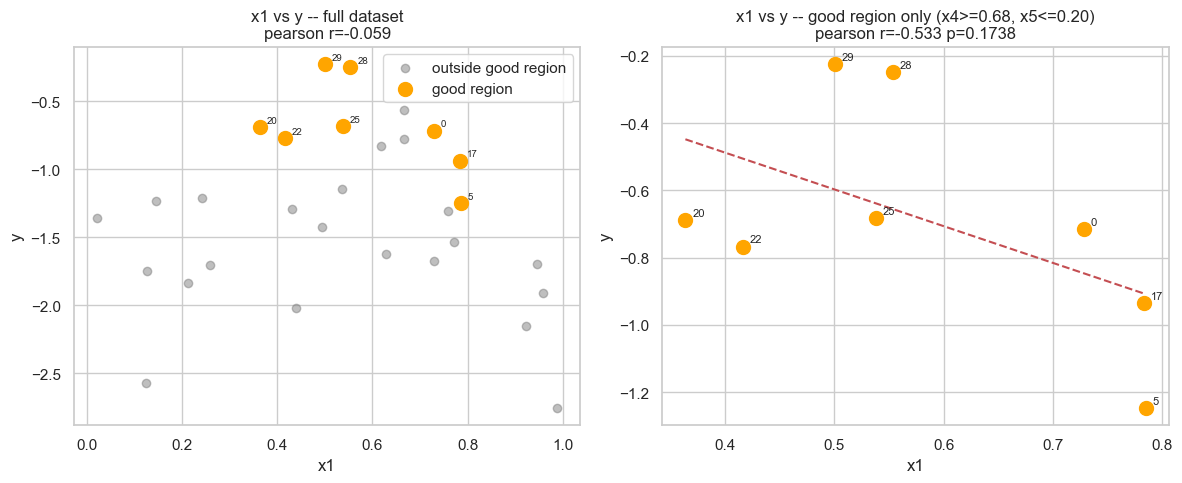

In [68]:
from scipy import stats

# define the good region: X4 >= 0.68 and X5 <= 0.20
# these are the current filter bounds from the week 11 strategy
mask_good_region = (X_train_6[:, 3] >= 0.68) & (X_train_6[:, 4] <= 0.20)

X_good = X_train_6[mask_good_region]
y_good = y_train_6[mask_good_region]

print(f"observations in good region (x4>=0.68, x5<=0.20): {mask_good_region.sum()}")
print(f"row indices: {np.where(mask_good_region)[0].tolist()}")
print(f"y values: {y_good}")
print(f"x1 values: {X_good[:, 0]}")

# correlation in full dataset vs conditional
r_full, p_full = stats.pearsonr(X_train_6[:, 0], y_train_6)
r_cond, p_cond = stats.pearsonr(X_good[:, 0], y_good) if len(y_good) > 3 else (np.nan, np.nan)

spear_full = stats.spearmanr(X_train_6[:, 0], y_train_6)
spear_cond = stats.spearmanr(X_good[:, 0], y_good) if len(y_good) > 3 else (np.nan, np.nan)

print(f"\nfull dataset  -- pearson r={r_full:.4f} p={p_full:.4f}")
print(f"good region   -- pearson r={r_cond:.4f} p={p_cond:.4f}")
print(f"full dataset  -- spearman r={spear_full.statistic:.4f} p={spear_full.pvalue:.4f}")
print(f"good region   -- spearman r={spear_cond.statistic:.4f} p={spear_cond.pvalue:.4f}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# full dataset
axes[0].scatter(X_train_6[:, 0], y_train_6, c='grey', alpha=0.5, label='outside good region')
axes[0].scatter(X_good[:, 0], y_good, c='orange', s=100, zorder=5, label='good region')
for i in np.where(mask_good_region)[0]:
    axes[0].annotate(str(i),
                     (X_train_6[i, 0], y_train_6[i]),
                     textcoords='offset points', xytext=(5, 3), fontsize=7)
axes[0].set_xlabel('x1')
axes[0].set_ylabel('y')
axes[0].set_title(f'x1 vs y -- full dataset\npearson r={r_full:.3f}')
axes[0].legend()

# conditional on good region
if len(y_good) > 3:
    axes[1].scatter(X_good[:, 0], y_good, c='orange', s=100)
    for i, (xi, yi) in enumerate(zip(X_good[:, 0], y_good)):
        axes[1].annotate(str(np.where(mask_good_region)[0][i]),
                         (xi, yi),
                         textcoords='offset points', xytext=(5, 3), fontsize=8)
    # add linear fit line
    m, b = np.polyfit(X_good[:, 0], y_good, 1)
    x_line = np.linspace(X_good[:, 0].min(), X_good[:, 0].max(), 50)
    axes[1].plot(x_line, m*x_line + b, 'r--', linewidth=1.5)
    axes[1].set_xlabel('x1')
    axes[1].set_ylabel('y')
    axes[1].set_title(f'x1 vs y -- good region only (x4>=0.68, x5<=0.20)\npearson r={r_cond:.3f} p={p_cond:.4f}')
else:
    axes[1].text(0.5, 0.5, f'only {len(y_good)} points in region\nnot enough for correlation',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('good region: insufficient data')

plt.tight_layout()
plt.savefig('x1_conditional_analysis.png', dpi=150)
plt.show()

In [69]:
# f6 strategy
# ml method: gaussian process regression with matern kernel and white noise
# objective: choose the next x that maximises expected improvement for f6
# rationale: use a probabilistic surrogate model to focus search where the function is high
# key assumptions:
#   1) there is a high value ridge in x4 and x5 inside a known subregion
#   2) x1 has a weaker but real effect and can be softly filtered
#   3) the gaussian process can approximate the function well enough to rank candidates
# exploration mechanism:
#   generate many candidate points in the promising subspace
#   remove points too close to existing data
#   use expected improvement to balance predicted value and uncertainty
#   pick the candidate with the highest expected improvement

def propose_f6_query(X_train_6, y_train_6):
    """
    propose the next evaluation point for f6 using ard gp and expected improvement
    X_train_6: numpy array of shape (n_samples, 5)
    y_train_6: numpy array of shape (n_samples,)
    """

    # step 1: basic diagnostics and current best
    best_idx = np.argmax(y_train_6)
    best_obs = y_train_6[best_idx]
    best_x = X_train_6[best_idx]

    print(f"n observations: {len(y_train_6)}")
    print(f"current best: {best_obs:.6f}")
    print(
        "location: "
        f"x1={best_x[0]:.4f} x2={best_x[1]:.4f} x3={best_x[2]:.4f} "
        f"x4={best_x[3]:.4f} x5={best_x[4]:.4f}"
    )

    # log the top 5 observations to see the ridge pattern
    top5_idx = np.argsort(y_train_6)[-5:][::-1]
    print("\ntop 5 observations:")
    for i in top5_idx:
        print(
            f"  row {i:2d}: "
            f"x1={X_train_6[i,0]:.3f} x2={X_train_6[i,1]:.3f} "
            f"x3={X_train_6[i,2]:.3f} x4={X_train_6[i,3]:.3f} "
            f"x5={X_train_6[i,4]:.3f} y={y_train_6[i]:.6f}"
        )


    # step 2: standardise outputs
    # this makes the target roughly zero mean and unit variance
    # it helps the gaussian process likelihood behave well
    y_mean = np.mean(y_train_6)
    y_std = np.std(y_train_6)
    y_scaled = (y_train_6 - y_mean) / y_std


    # step 3: define and fit the gaussian process
    # constant kernel times matern gives a flexible smooth model
    # white kernel models small observation noise
    # ard means each input dimension has its own length scale
    kernel = (
        ConstantKernel(1.0, constant_value_bounds=(0.01, 10.0))
        * Matern(
            length_scale=[1.0] * 5,
            length_scale_bounds=[(0.05, 10.0)] * 5,
            nu=2.5,
        )
        + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-6, 0.5))
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=30,
        normalize_y=False,
        alpha=1e-6,
    )

    gp.fit(X_train_6, y_scaled)
    print("\nfitted kernel:")
    print(gp.kernel_)

    # inspect learned length scales to see which dimensions are active
    try:
        ls = gp.kernel_.k1.k2.length_scale
        print("\nlearned length scales:")
        labels = ["x1", "x2", "x3", "x4", "x5"]
        for label, val in zip(labels, ls):
            if val < 0.7:
                status = "short/active"
            elif val > 5.0:
                status = "long/inactive"
            else:
                status = "moderate"
            print(f"  {label}: {val:.4f} [{status}]")
        print(f"  spread (std): {np.std(ls):.4f}")
        print("  note: x1 mutual information emerged, so watch x1 length scale")
    except Exception as e:
        print(f"length scale error: {e}")

  
    # step 4: sobol candidate generation with tightened cluster 1 filter
    # we generate many candidates in [0,1]^5 then keep only those
    # inside the empirically good region for x4 and x5 and with a soft filter on x1
    # this focuses exploration on the known high value basin
    N_SOBOL = 15000
    MIN_DIST = 0.05
    EI_XI = 0.003  # small xi encourages exploitation near the current best

    sampler = Sobol(d=5, scramble=True, seed=42)
    raw = sampler.random(N_SOBOL)

    # apply subspace filters
    mask = (
        (raw[:, 3] >= 0.68)  # x4 lower bound
        & (raw[:, 3] <= 0.88)  # x4 upper bound
        & (raw[:, 4] >= 0.02)  # x5 lower bound
        & (raw[:, 4] <= 0.18)  # x5 upper bound
        & (raw[:, 0] <= 0.70)  # x1 soft upper bound
        & ~((raw[:, 3] > 0.92) & (raw[:, 4] < 0.02))  # exclude bad corner
    )
    candidates = raw[mask].copy()
    print(f"\nafter tightened filter: {len(candidates)} from {N_SOBOL}")

    # if too few candidates remain, relax the filter slightly
    if len(candidates) < 50:
        print("warning: filter too tight, relaxing x1 and x5 ranges")
        mask_relaxed = (
            (raw[:, 3] >= 0.68)
            & (raw[:, 3] <= 0.88)
            & (raw[:, 4] >= 0.02)
            & (raw[:, 4] <= 0.22)
            & (raw[:, 0] <= 0.80)
            & ~((raw[:, 3] > 0.92) & (raw[:, 4] < 0.02))
        )
        candidates = raw[mask_relaxed].copy()
        print(f"after relaxed filter: {len(candidates)} candidates")


    # step 5: minimum distance guard
    # this prevents selecting candidates that are too close
    # to existing observations, so each new evaluation is informative
    min_dists = np.array(
        [np.min(np.linalg.norm(X_train_6 - c, axis=1)) for c in candidates]
    )
    candidates_clean = candidates[min_dists >= MIN_DIST]
    print(f"after dist guard (>= {MIN_DIST}): {len(candidates_clean)} remain")

    if len(candidates_clean) < 10:
        print("warning: relaxing dist guard to 0.03")
        candidates_clean = candidates[min_dists >= 0.03]
        print(f"after relaxed dist guard: {len(candidates_clean)} remain")

    if len(candidates_clean) == 0:
        raise RuntimeError("no valid candidates after distance guard")

    # step 6: expected improvement acquisition
    # ei balances predicted mean and uncertainty from the gp
    # we compute ei for each candidate and pick the best one
    mu_s, sig_s = gp.predict(candidates_clean, return_std=True)
    mu = mu_s * y_std + y_mean
    sigma = sig_s * y_std

    safe_sigma = np.where(sigma > 1e-9, sigma, 1e-9)
    z = (mu - best_obs - EI_XI) / safe_sigma
    ei = np.where(
        sigma > 1e-9,
        (mu - best_obs - EI_XI) * norm.cdf(z) + sigma * norm.pdf(z),
        0.0,
    )

    ranked = np.argsort(ei)[::-1]
    top_idx = ranked[0]
    top_x = candidates_clean[top_idx]

    print("\ntop ei candidate")
    for i, label in enumerate(["x1", "x2", "x3", "x4", "x5"]):
        print(f"{label} = {top_x[i]:.6f}")
    print(f"ei score:       {ei[top_idx]:.8f}")
    print(f"predicted mean: {mu[top_idx]:.6f}")
    print(f"predicted std:  {sigma[top_idx]:.6f}")
    print(f"dist to best:   {np.linalg.norm(top_x - best_x):.4f}")


    # step 7: boundary check
    # we avoid points exactly at the domain edges
    # this reduces the risk of numerical issues and extreme extrapolation
    boundary_issues = []
    for i, label in enumerate(["x1", "x2", "x3", "x4", "x5"]):
        if top_x[i] <= 0.001 or top_x[i] >= 0.999:
            boundary_issues.append(f"{label}={top_x[i]:.4f}")
    if boundary_issues:
        print(f"warning: boundary collapse detected: {boundary_issues}")
        print("inspect top 5 and select a rank with no boundary issues")
    else:
        print("boundary check: ok, no dimension at domain edge")


    # step 8: show top 5 candidates for inspection
    # this helps understand how the exploration behaves
    print("\ntop 5 candidates")
    for rank, idx in enumerate(ranked[:5]):
        c = candidates_clean[idx]
        d = np.min(np.linalg.norm(X_train_6 - c, axis=1))
        boundary_flags = []
        for j in range(5):
            if c[j] <= 0.001 or c[j] >= 0.999:
                boundary_flags.append(f"x{j+1} boundary")
        flag = ", ".join(boundary_flags) if boundary_flags else "ok"
        print(
            f"rank {rank+1}: "
            f"x1={c[0]:.4f} x2={c[1]:.4f} x3={c[2]:.4f} "
            f"x4={c[3]:.4f} x5={c[4]:.4f} | "
            f"ei={ei[idx]:.6f} mu={mu[idx]:.4f} sig={sigma[idx]:.4f} "
            f"d={d:.3f} | {flag}"
        )


    # step 9: final summary and recommended submission
    print("\nfinal submission for f6")
    for i, label in enumerate(["x1", "x2", "x3", "x4", "x5"]):
        print(f"{label} = {top_x[i]:.6f}")
    print(f"\ncurrent best: {best_obs:.6f}")

    return top_x, gp, y_std, y_mean

top_x, gp_f6, y_std, y_mean  = propose_f6_query(X_train_6, y_train_6)

n observations: 30
current best: -0.224425
location: x1=0.5002 x2=0.4410 x3=0.6074 x4=0.7499 x5=0.0640

top 5 observations:
  row 29: x1=0.500 x2=0.441 x3=0.607 x4=0.750 x5=0.064 y=-0.224425
  row 28: x1=0.553 x2=0.343 x3=0.535 x4=0.772 x5=0.141 y=-0.249360
  row 21: x1=0.666 x2=0.229 x3=0.516 x4=0.822 x5=0.202 y=-0.564857
  row 25: x1=0.538 x2=0.404 x3=0.952 x4=0.943 x5=0.051 y=-0.681459
  row 20: x1=0.364 x2=0.001 x3=0.921 x4=0.821 x5=0.136 y=-0.687242

fitted kernel:
1.21**2 * Matern(length_scale=[0.484, 10, 1.69, 0.464, 0.887], nu=2.5) + WhiteKernel(noise_level=1e-06)

learned length scales:
  x1: 0.4838 [short/active]
  x2: 10.0000 [long/inactive]
  x3: 1.6891 [moderate]
  x4: 0.4639 [short/active]
  x5: 0.8874 [moderate]
  spread (std): 3.6745
  note: x1 mutual information emerged, so watch x1 length scale

after tightened filter: 337 from 15000
after dist guard (>= 0.05): 336 remain

top ei candidate
x1 = 0.548528
x2 = 0.190888
x3 = 0.279484
x4 = 0.804716
x5 = 0.020038
ei score:

## Empirical Variogram

**Reference:** Rasmussen, C.E. and Williams, C.K.I. (2006) Gaussian Processes for Machine Learning. MIT Press.

- The empirical variogram checks whether the GP’s fitted length scales—especially the short X4 scale—match the true correlation structure in the f6 data, revealing over‑ or under‑smoothness that directly affects surrogate reliability.

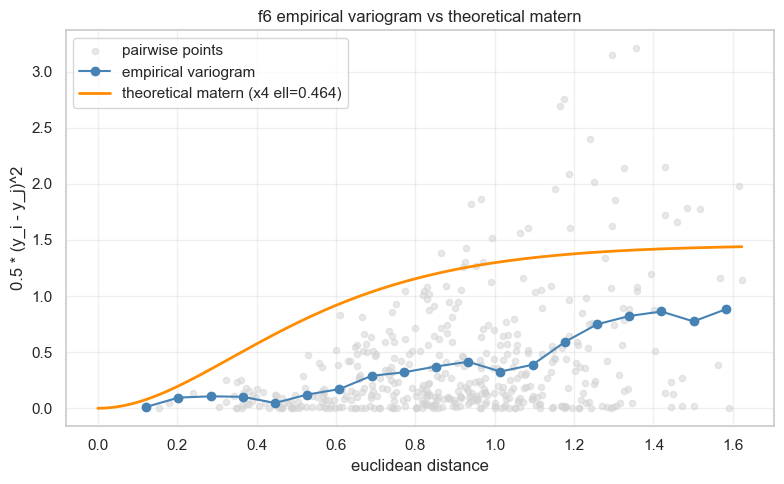

fitted x4 length scale: 0.4639
theoretical sill (variance): 1.4565
variogram should reach sill near distance ≈ 2 * ell4
expected sill distance ≈ 0.928


In [70]:
# empirical variogram for f6

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

def empirical_variogram_f6(X_train_6, y_train_6, gp_f6):
    # pairwise euclidean distances in 5d
    D = squareform(pdist(X_train_6, metric="euclidean"))

    # squared differences in y
    Ydiff2 = squareform(pdist(y_train_6.reshape(-1,1),
                              metric=lambda u,v: (u-v)**2))

    # flatten upper triangle
    dists = D[np.triu_indices_from(D, k=1)]
    sqdiff = Ydiff2[np.triu_indices_from(Ydiff2, k=1)]

    # bin distances
    n_bins = 20
    bins = np.linspace(0, dists.max(), n_bins+1)
    bin_centres = 0.5 * (bins[:-1] + bins[1:])
    emp_var = np.zeros(n_bins)

    for i in range(n_bins):
        mask = (dists >= bins[i]) & (dists < bins[i+1])
        if mask.sum() > 0:
            emp_var[i] = 0.5 * np.mean(sqdiff[mask])
        else:
            emp_var[i] = np.nan

    # extract matern parameters from fitted gp
    k = gp_f6.kernel_.k1
    lengthscales = np.asarray(k.k2.length_scale)
    variance = k.k1.constant_value

    # theoretical matern 2.5 variogram along x4 direction
    ell4 = lengthscales[3]
    r_theory = np.linspace(0, dists.max(), 200)

    sqrt5 = np.sqrt(5.0)
    cov_theory = variance * (
        1 + sqrt5*r_theory/ell4 + 5*(r_theory**2)/(3*ell4**2)
    ) * np.exp(-sqrt5*r_theory/ell4)

    var_theory = variance - cov_theory

    # plot
    plt.figure(figsize=(8,5))
    plt.scatter(dists, 0.5*sqdiff, c="lightgray", s=20, alpha=0.5,
                label="pairwise points")
    plt.plot(bin_centres, emp_var, "o-", color="steelblue",
             label="empirical variogram")
    plt.plot(r_theory, var_theory, color="darkorange", linewidth=2,
             label=f"theoretical matern (x4 ell={ell4:.3f})")

    plt.xlabel("euclidean distance")
    plt.ylabel("0.5 * (y_i - y_j)^2")
    plt.title("f6 empirical variogram vs theoretical matern")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"fitted x4 length scale: {ell4:.4f}")
    print(f"theoretical sill (variance): {variance:.4f}")
    print("variogram should reach sill near distance ≈ 2 * ell4")
    print(f"expected sill distance ≈ {2*ell4:.3f}")


empirical_variogram_f6(X_train_6, y_train_6, gp_f6)


## GP Posterior Mean 2D Slice Plots

**References:** 
- Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2022) Latent Space Bayesian Optimization via Neural Embeddings, arXiv preprint arXiv:2201.XXXX.
  
- Eriksson, D. and Jankowiak, M. (2021) ‘High‑Dimensional Bayesian Optimization with Sparse Axis‑Aligned Subspaces’, Advances in Neural Information Processing Systems, 34, pp. 11048–11060.

- Posterior‑mean slice plots expose the GP’s believed ridge geometry around the incumbent, making it immediately visible whether the surrogate predicts continuation, termination, or curvature in the X4–X5 basin and whether any structure remains in X1–X3.

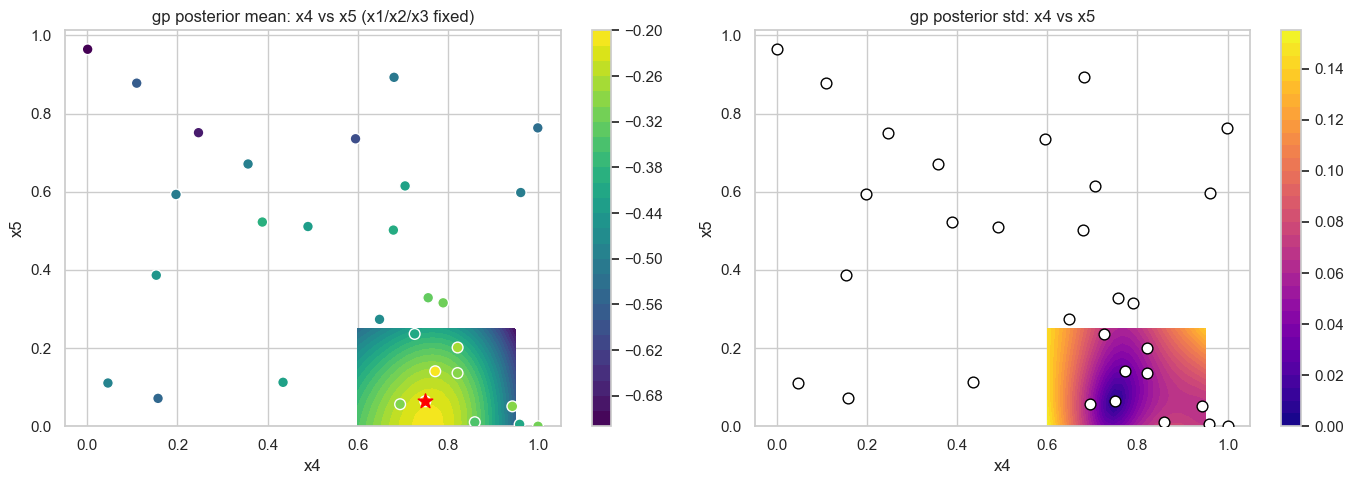

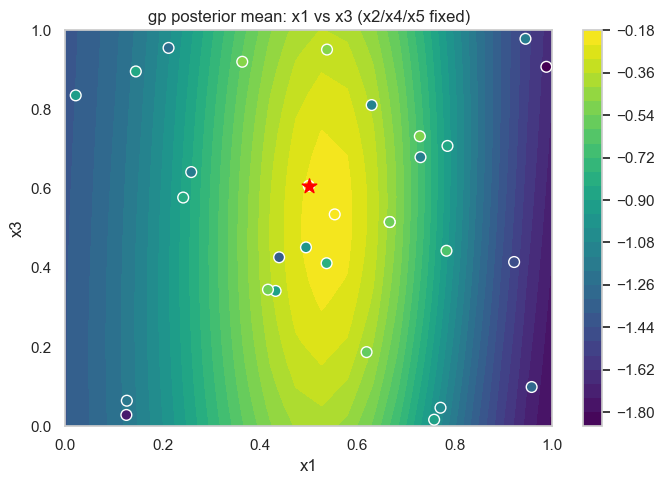

In [71]:
best_x_f6 = X_train_6[np.argmax(y_train_6)]

n_grid = 20

# slice 1: x4 vs x5, fix x1/x2/x3 at incumbent
x4_range = np.linspace(0.60, 0.95, n_grid)
x5_range = np.linspace(0.00, 0.25, n_grid)
X4, X5 = np.meshgrid(x4_range, x5_range)

grid_slice1 = np.column_stack([
    np.full(n_grid*n_grid, best_x_f6[0]),
    np.full(n_grid*n_grid, best_x_f6[1]),
    np.full(n_grid*n_grid, best_x_f6[2]),
    X4.ravel(),
    X5.ravel()
])

mu_s, sig_s = gp_f6.predict(grid_slice1, return_std=True)
mu_slice1 = (mu_s * y_std + y_mean).reshape(n_grid, n_grid)
sig_slice1 = (sig_s * y_std).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].contourf(x4_range, x5_range, mu_slice1, levels=30, cmap='viridis')
axes[0].scatter(X_train_6[:, 3], X_train_6[:, 4],
                c=y_train_6, cmap='viridis', edgecolors='white', s=60, zorder=5)
axes[0].scatter(best_x_f6[3], best_x_f6[4],
                c='red', s=120, marker='*', zorder=6)
axes[0].set_xlabel('x4')
axes[0].set_ylabel('x5')
axes[0].set_title('gp posterior mean: x4 vs x5 (x1/x2/x3 fixed)')
plt.colorbar(im, ax=axes[0])

im2 = axes[1].contourf(x4_range, x5_range, sig_slice1, levels=30, cmap='plasma')
axes[1].scatter(X_train_6[:, 3], X_train_6[:, 4],
                c='white', edgecolors='black', s=60, zorder=5)
axes[1].set_xlabel('x4')
axes[1].set_ylabel('x5')
axes[1].set_title('gp posterior std: x4 vs x5')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

# slice 2: x1 vs x3, fix x2/x4/x5 at incumbent
x1_range = np.linspace(0.0, 1.0, n_grid)
x3_range = np.linspace(0.0, 1.0, n_grid)
X1, X3 = np.meshgrid(x1_range, x3_range)

grid_slice2 = np.column_stack([
    X1.ravel(),
    np.full(n_grid*n_grid, best_x_f6[1]),
    X3.ravel(),
    np.full(n_grid*n_grid, best_x_f6[3]),
    np.full(n_grid*n_grid, best_x_f6[4])
])

mu_s2, sig_s2 = gp_f6.predict(grid_slice2, return_std=True)
mu_slice2 = (mu_s2 * y_std + y_mean).reshape(n_grid, n_grid)

fig2, ax2 = plt.subplots(figsize=(7, 5))
im3 = ax2.contourf(x1_range, x3_range, mu_slice2, levels=30, cmap='viridis')
ax2.scatter(X_train_6[:, 0], X_train_6[:, 2],
            c=y_train_6, cmap='viridis', edgecolors='white', s=60, zorder=5)
ax2.scatter(best_x_f6[0], best_x_f6[2],
            c='red', s=120, marker='*', zorder=6)
ax2.set_xlabel('x1')
ax2.set_ylabel('x3')
ax2.set_title('gp posterior mean: x1 vs x3 (x2/x4/x5 fixed)')
plt.colorbar(im3, ax=ax2)
plt.tight_layout()
plt.show()
